Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

• Manual invoice review is time-consuming and does not scale with transaction volume.
• Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
• An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically. """

In [1]:

import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

conn = sqlite3.connect("../data/inventory.db")

In [3]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [4]:

for table in tables['name']:
    print('Table Name', table)
    df = pd.read_sql_query(f'Select * from {table} limit 5', conn)
    display(df)

Table Name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df = pd.read_sql_query("""
select
PONumber,
count(distinct(Brand)) as total_brand,                                 
sum(Quantity) as total_item_quantity,
sum(Dollars) as total_item_dollars,
avg(julianday(ReceivingDate) - julianday(PODate)) as avg_receiving_delay
from purchases
group by PONumber                                                                                          
""", conn)

In [6]:
purchase_agg_df 

,PONumber,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [7]:

purchase_agg_df.shape

(5543, 5)

In [8]:
pd.read_sql_query("""
select
Quantity as invoice_quantity,                 
Dollars as invoice_dollars,
Freight,
(julianday(InvoiceDate) - julianday(PODate)) as days_po_to_invoice,
(julianday(PayDate) - julianday(InvoiceDate)) as days_to_pay                                                
from vendor_invoice """,conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [9]:
df = pd.read_sql_query("""

With Purchase_agg as(
select
p.PONumber,
count(distinct(p.Brand)) as total_brand,                                 
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber                  
)                                  
select
    vi.Quantity as invoice_quantity,                 
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
    pa.total_brand,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay                                                                  
from vendor_invoice vi  
left join purchase_agg pa
on vi.PONumber = pa.PONumber                                                                
""",conn)

In [10]:

df ## final table for machine leanring and for analysis

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
0,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [11]:

df.isnull().sum() ## data m koi null value toh ni h...

invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brand            0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [12]:
df.dtypes

invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brand              int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [13]:

df.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,35.0,41.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,6.0,77.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,23.0,1.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,31.0,3.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,35.0,7.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,40.0,46.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,48.0,807.0,141660.0,1660436.0,13.0


In [14]:
def create_invoice_risk_label(row):
    
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"])) > 5:
        return 1
    
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

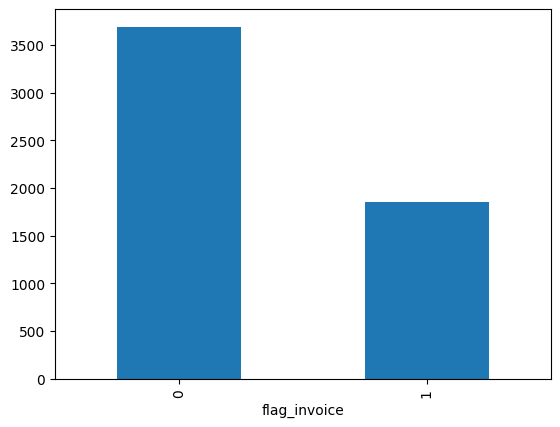

In [15]:
df['flag_invoice'].value_counts().plot(kind = 'bar') ## data balance toh ni h lekin bohot jada imbalance bhi ni h...

In [16]:
df.corr()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brand,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
invoice_quantity,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brand,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667
flag_invoice,0.032783,0.037994,0.037759,0.183115,-0.005289,0.008961,0.032783,0.037994,0.311667,1.000000


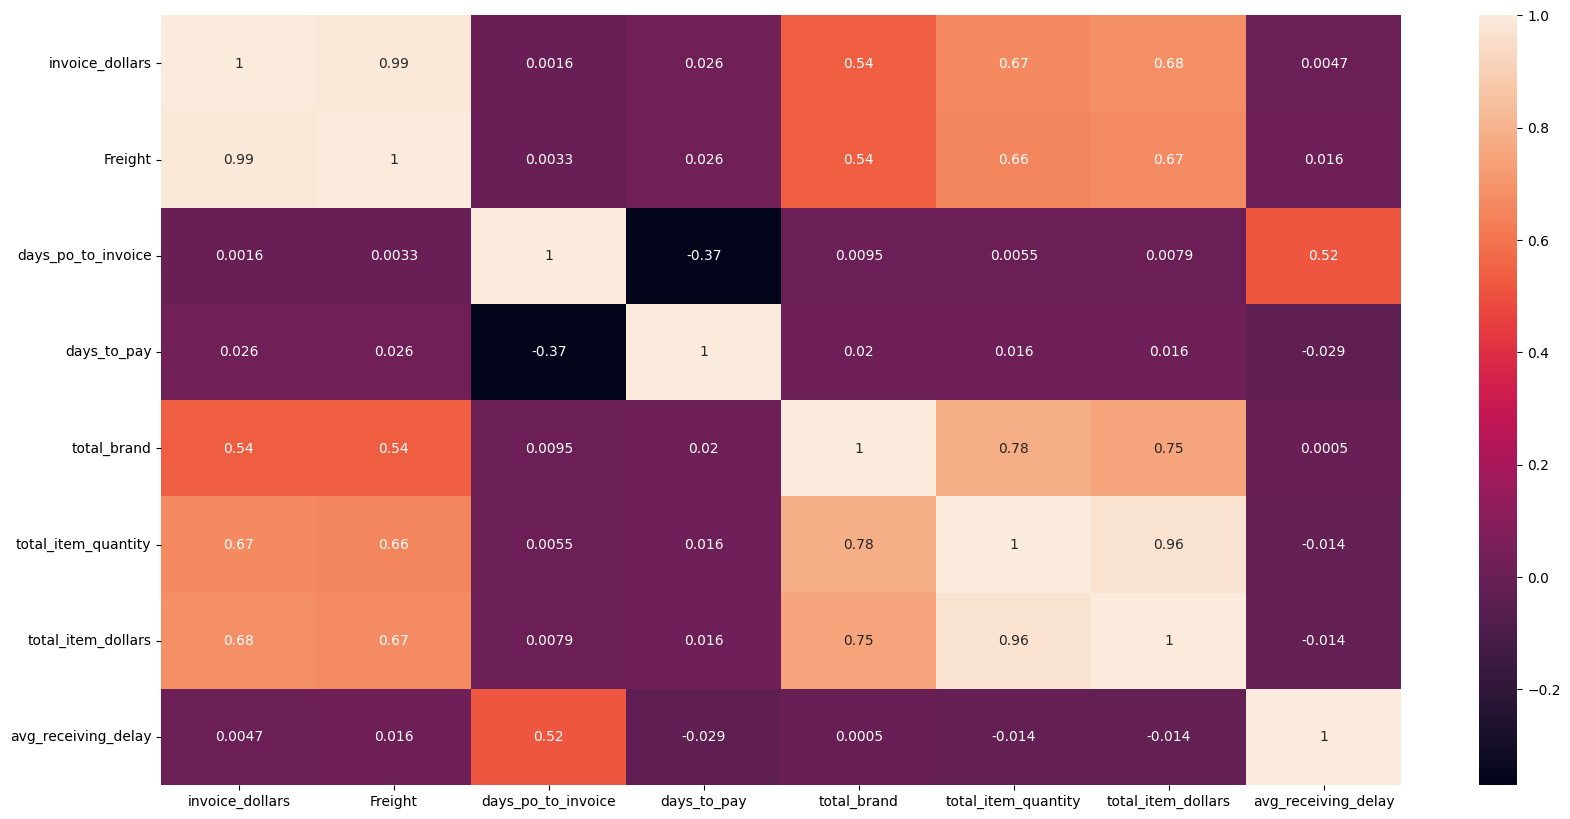

In [17]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot= True)
plt.show()

In [19]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [20]:
significant_features =[]
nonsignificant_features = []
results = []


In [21]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
           'days_po_to_invoice', 'days_to_pay', 'total_brand',
           'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [32]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        nonsignificant_features.append(metric)

        print(metric)
        print({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': 35.42, 'normal_mean': 35.49, 'p_value': 0.692}
total_brand
{'metric': 'total_brand', 'flagged_mean': 42.29, 'normal_mean': 40.82, 'p_value': 0.508}


In [33]:
nonsignificant_features

['days_to_pay', 'total_brand', 'days_to_pay', 'days_to_pay', 'total_brand']

In [34]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [35]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0},
 {'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'norma

In [36]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight','total_brand', 'total_item_quantity','days_po_to_invoice', 'total_item_dollars']]
y = df['flag_invoice']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [47]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)


RandomForestClassifier(random_state=42)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    print(f"\n{model_name} Performance:")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 2))
    print("Classification Report :")
    print(classification_report(y_test, y_pred))

In [50]:
evaluate_model(model1,X_test_scaled,y_test,'Logistic Regression')
evaluate_model(model2,X_test_scaled,y_test,'Decision Tree Classifier')
evaluate_model(model3,X_test_scaled,y_test,'Random Forest Classifier')


Logistic Regression Performance:
Accuracy : 0.67
Classification Report :
              precision    recall  f1-score   support

           0       0.68      0.98      0.80       739
           1       0.58      0.06      0.11       370

    accuracy                           0.67      1109
   macro avg       0.63      0.52      0.45      1109
weighted avg       0.64      0.67      0.57      1109


Decision Tree Classifier Performance:
Accuracy : 0.82
Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       739
           1       0.74      0.71      0.72       370

    accuracy                           0.82      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.82      0.82      0.82      1109


Random Forest Classifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       739
     

In [52]:
model3.feature_importances_

array([0.14257186, 0.15599333, 0.14511359, 0.08319226, 0.17707859,
       0.07633957, 0.2197108 ])

In [53]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.219711
4,total_item_quantity,0.177079
1,invoice_dollars,0.155993
2,Freight,0.145114
0,invoice_quantity,0.142572
3,total_brand,0.083192
5,days_po_to_invoice,0.076340


In [54]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
        'total_item_quantity', 'total_item_dollars']]

y = df['flag_invoice']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)   

evaluate_model(model3,X_test_scaled,y_test,'Random Forest Classifier')


Random Forest Classifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.93      0.71      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [60]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled,y_test,'Random Forest Classifier')               


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.89
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



In [61]:
from sklearn.metrics import confusion_matrix

In [63]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[713, 110],
       [ 12, 274]])

In [65]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[705, 110],
       [ 20, 274]])

In [66]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}